<a href="https://colab.research.google.com/github/aragaoian/ai-assignments/blob/master/M1_IAI_IanAragao_JoaoFraga_MariaMartim.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importação das bibliotecas

In [ ]:
from tensorflow import keras
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

# Importação do Dataset

In [ ]:
!pip install ucimlrepo

from ucimlrepo import fetch_ucirepo

dry_bean = fetch_ucirepo(id=602)

X = dry_bean.data.features
y = dry_bean.data.targets

df = pd.concat([X, y], axis=1)

# 1.1 Inspeção inicial

In [ ]:
print('Informações do dataset:')
df.info()

print('\n\nDescrição do dataset:')
df.describe()

print('\n\nTotal de classes:')
df['Class'].value_counts().sort_index()

Informações do dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRatio      13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  int64  
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  Roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFactor3     13611 non-null  float64
 15  ShapeFactor4     13611 non-null  float64
 16  Class            13611 non-null  o

,count
Class,
BARBUNYA,1322
BOMBAY,522
CALI,1630
DERMASON,3546
HOROZ,1928
SEKER,2027
SIRA,2636


1. Quantas linhas e colunas o dataset possui? E o esperado conforme a documentação do UCI?
**O dataset possui 13611 linhas e 17 colunas (conforme a documentação).**

2. Ha valores ausentes? De que tipo são as features?
**Não existem valores nulos.**

3. Existem classes com muito menos amostras? O que isso pode causar no treinamento?    Como a acurácia pode nos enganar nesse caso? **A classe BOMBAY possui bem menos amostras quando comparada com as demais (possui 522 enquanto as demais giram em torno de 2000 e 3000, sendo o mínimo 1630). O treinamento pode ser extremamente prejudicado por isso, ocorrendo problemas como o viés para classe majoritária (rede neural dando pouca importância devido ao pequeno número de amostras), possível diminuição da acurácia se tratando dessa classe devido ao baixo número de amostras, possível overfitting por existirem poucos dados para treinamento e dificuldade na convergência (O gradiente descendente pode ficar instável ou o treinamento pode estagnar, pois as poucas amostras da classe minoritária não fornecem informações suficientes para atualizar os pesos de forma consistente, tornando o aprendizado lento ou ineficaz). A acurácia pode ser enganosa em datasets desbalanceados porque um modelo pode obter alta acurácia apenas prevendo sempre a classe majoritária, ignorando completamente a classe minoritária, o que resulta em baixo desempenho real.**


# 1.2 Verificação e remoção de duplicatas

In [ ]:
print(f'Número de dados duplicados no dataframe: {df.duplicated().sum()}')

Número de dados duplicados no dataframe: 68


4. Quantos registros duplicados foram encontrados? Qual seria o impacto de mantê-los? **Foram encontrados 68 registros duplicados. Dentre os principais problemas em manter os dados duplicados no dataframe pode-se citar o viés de treinamento (rede neural dando ênfase para dados repetidos, como se fosse mais importantes), overfitting (rede neural decorando os dados que aparecem muitas vezes) e dados duplicados no teste e validação (fazendo com que a rede neural valide se aprendeu corretamente com os dados que foram usados no treinamento)**

# 1.3 Distribuição das features

Histograma dos dados numéricos:


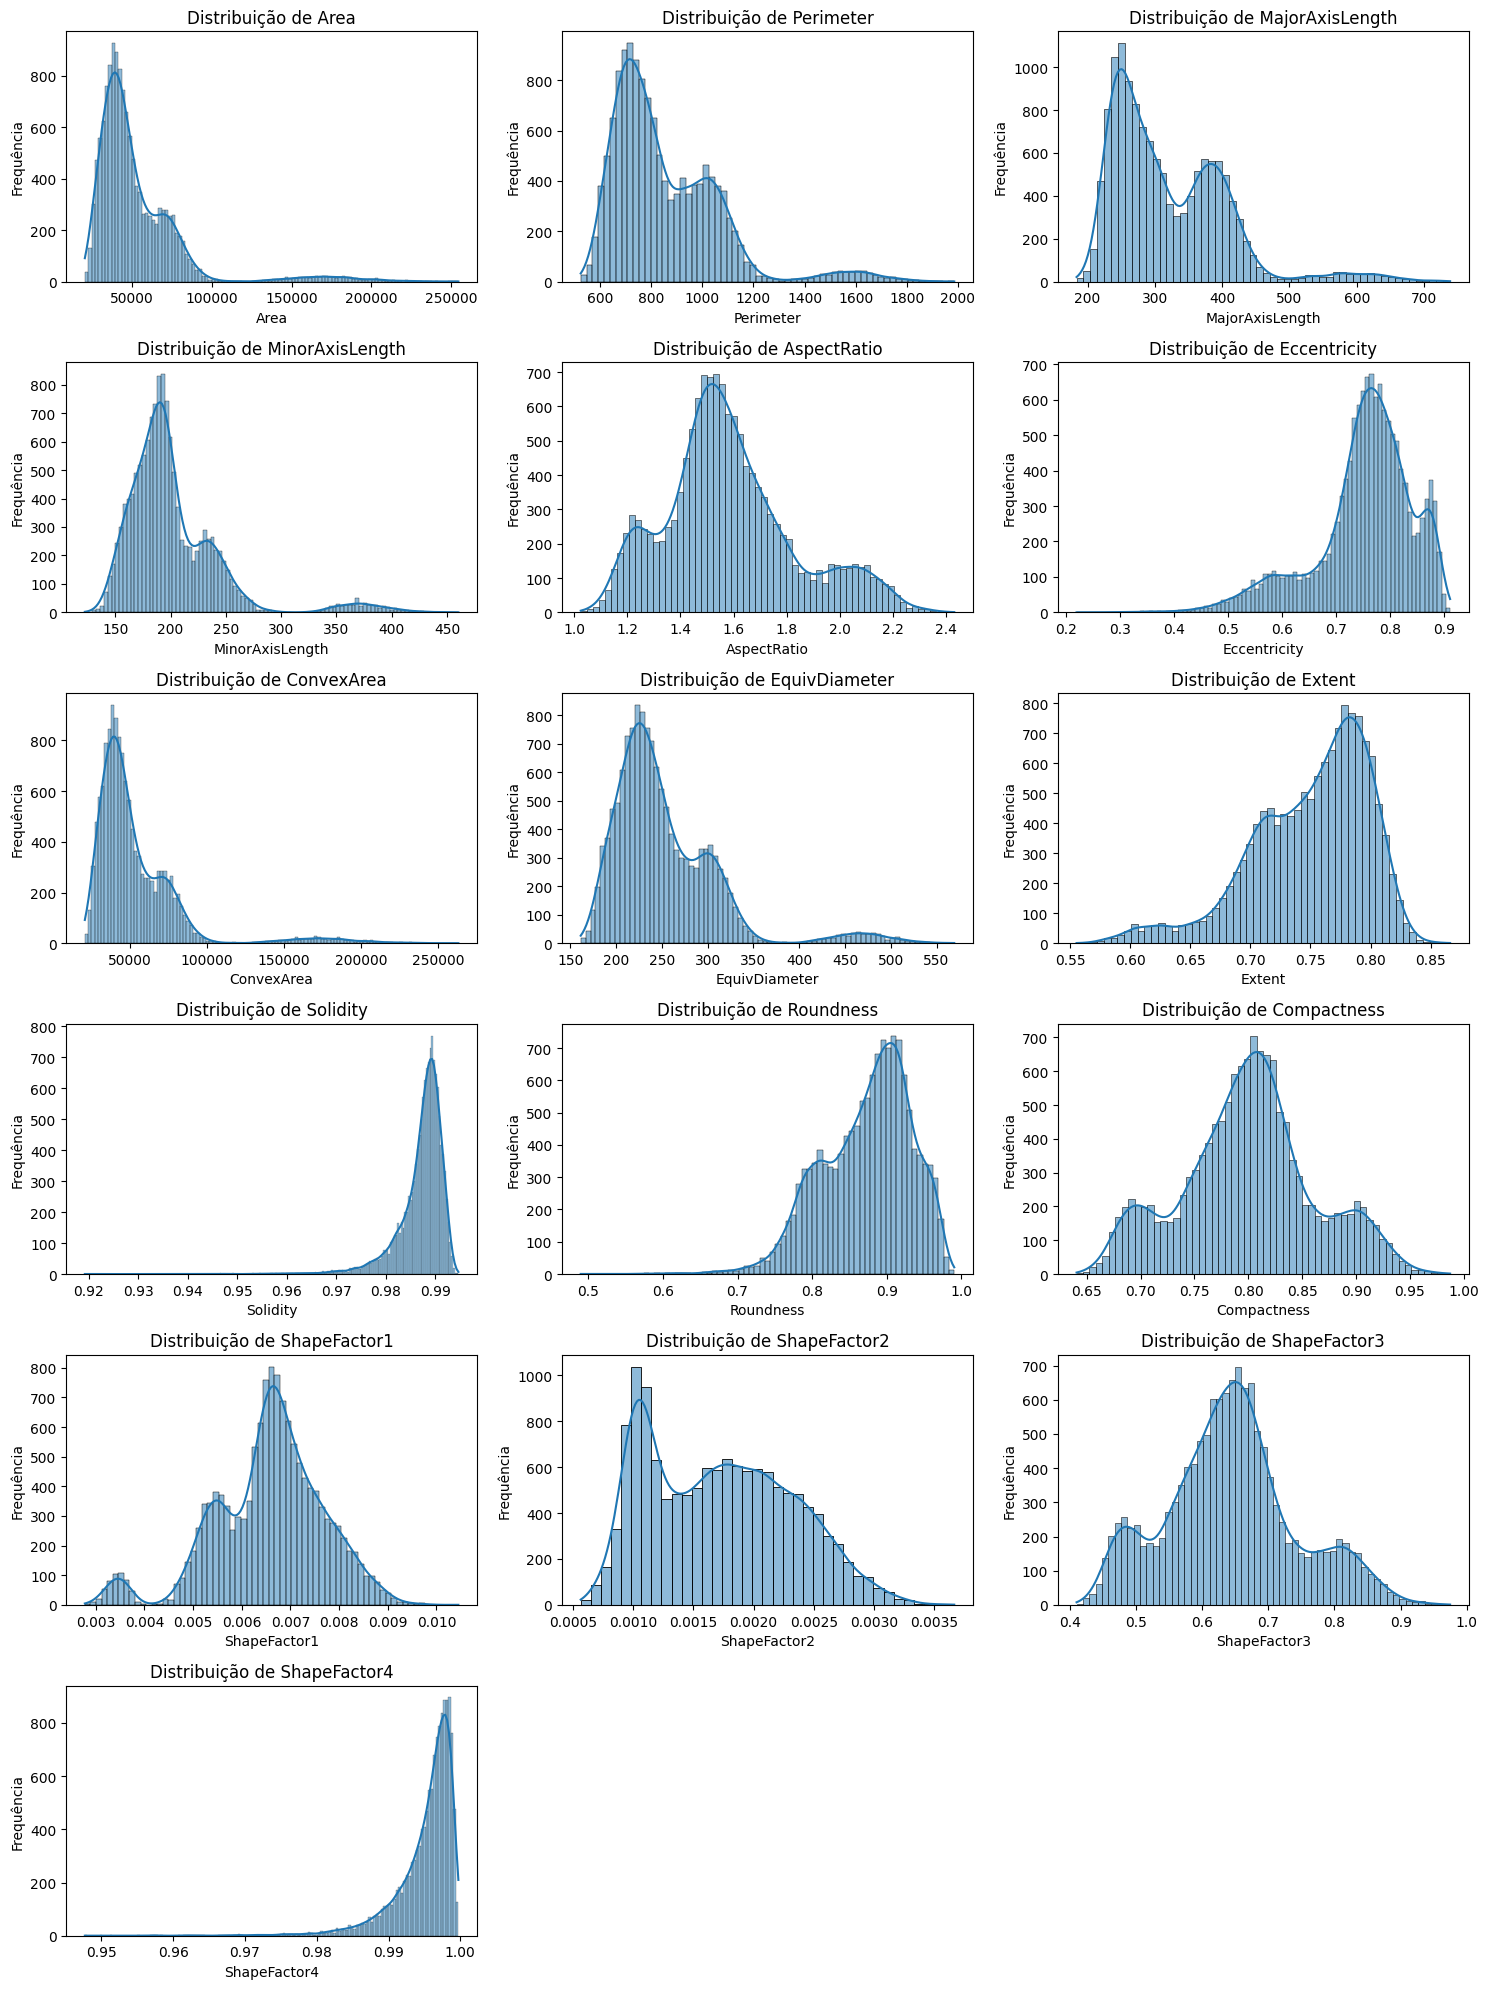

In [ ]:
import math

numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(15, 20))

n_cols = 3
n_rows = math.ceil(len(numerical_cols) / n_cols)

for i, col in enumerate(numerical_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribuição de {col}')
    plt.xlabel(col)
    plt.ylabel('Frequência')

print('Histograma dos dados numéricos:')
plt.tight_layout()
plt.show()

Skewness original:
ShapeFactor4      -2.759483
Solidity          -2.550093
Eccentricity      -1.062824
Extent            -0.895348
Roundness         -0.635749
ShapeFactor1      -0.534141
Compactness        0.037115
ShapeFactor3       0.242481
ShapeFactor2       0.301226
AspectRatio        0.582573
MajorAxisLength    1.357815
Perimeter          1.626124
EquivDiameter      1.948958
MinorAxisLength    2.238211
ConvexArea         2.941821
Area               2.952931
dtype: float64

Colunas que receberão log1p:
['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength', 'ConvexArea', 'EquivDiameter']

Histograma após aplicar log apenas nas features com assimetria positiva forte:


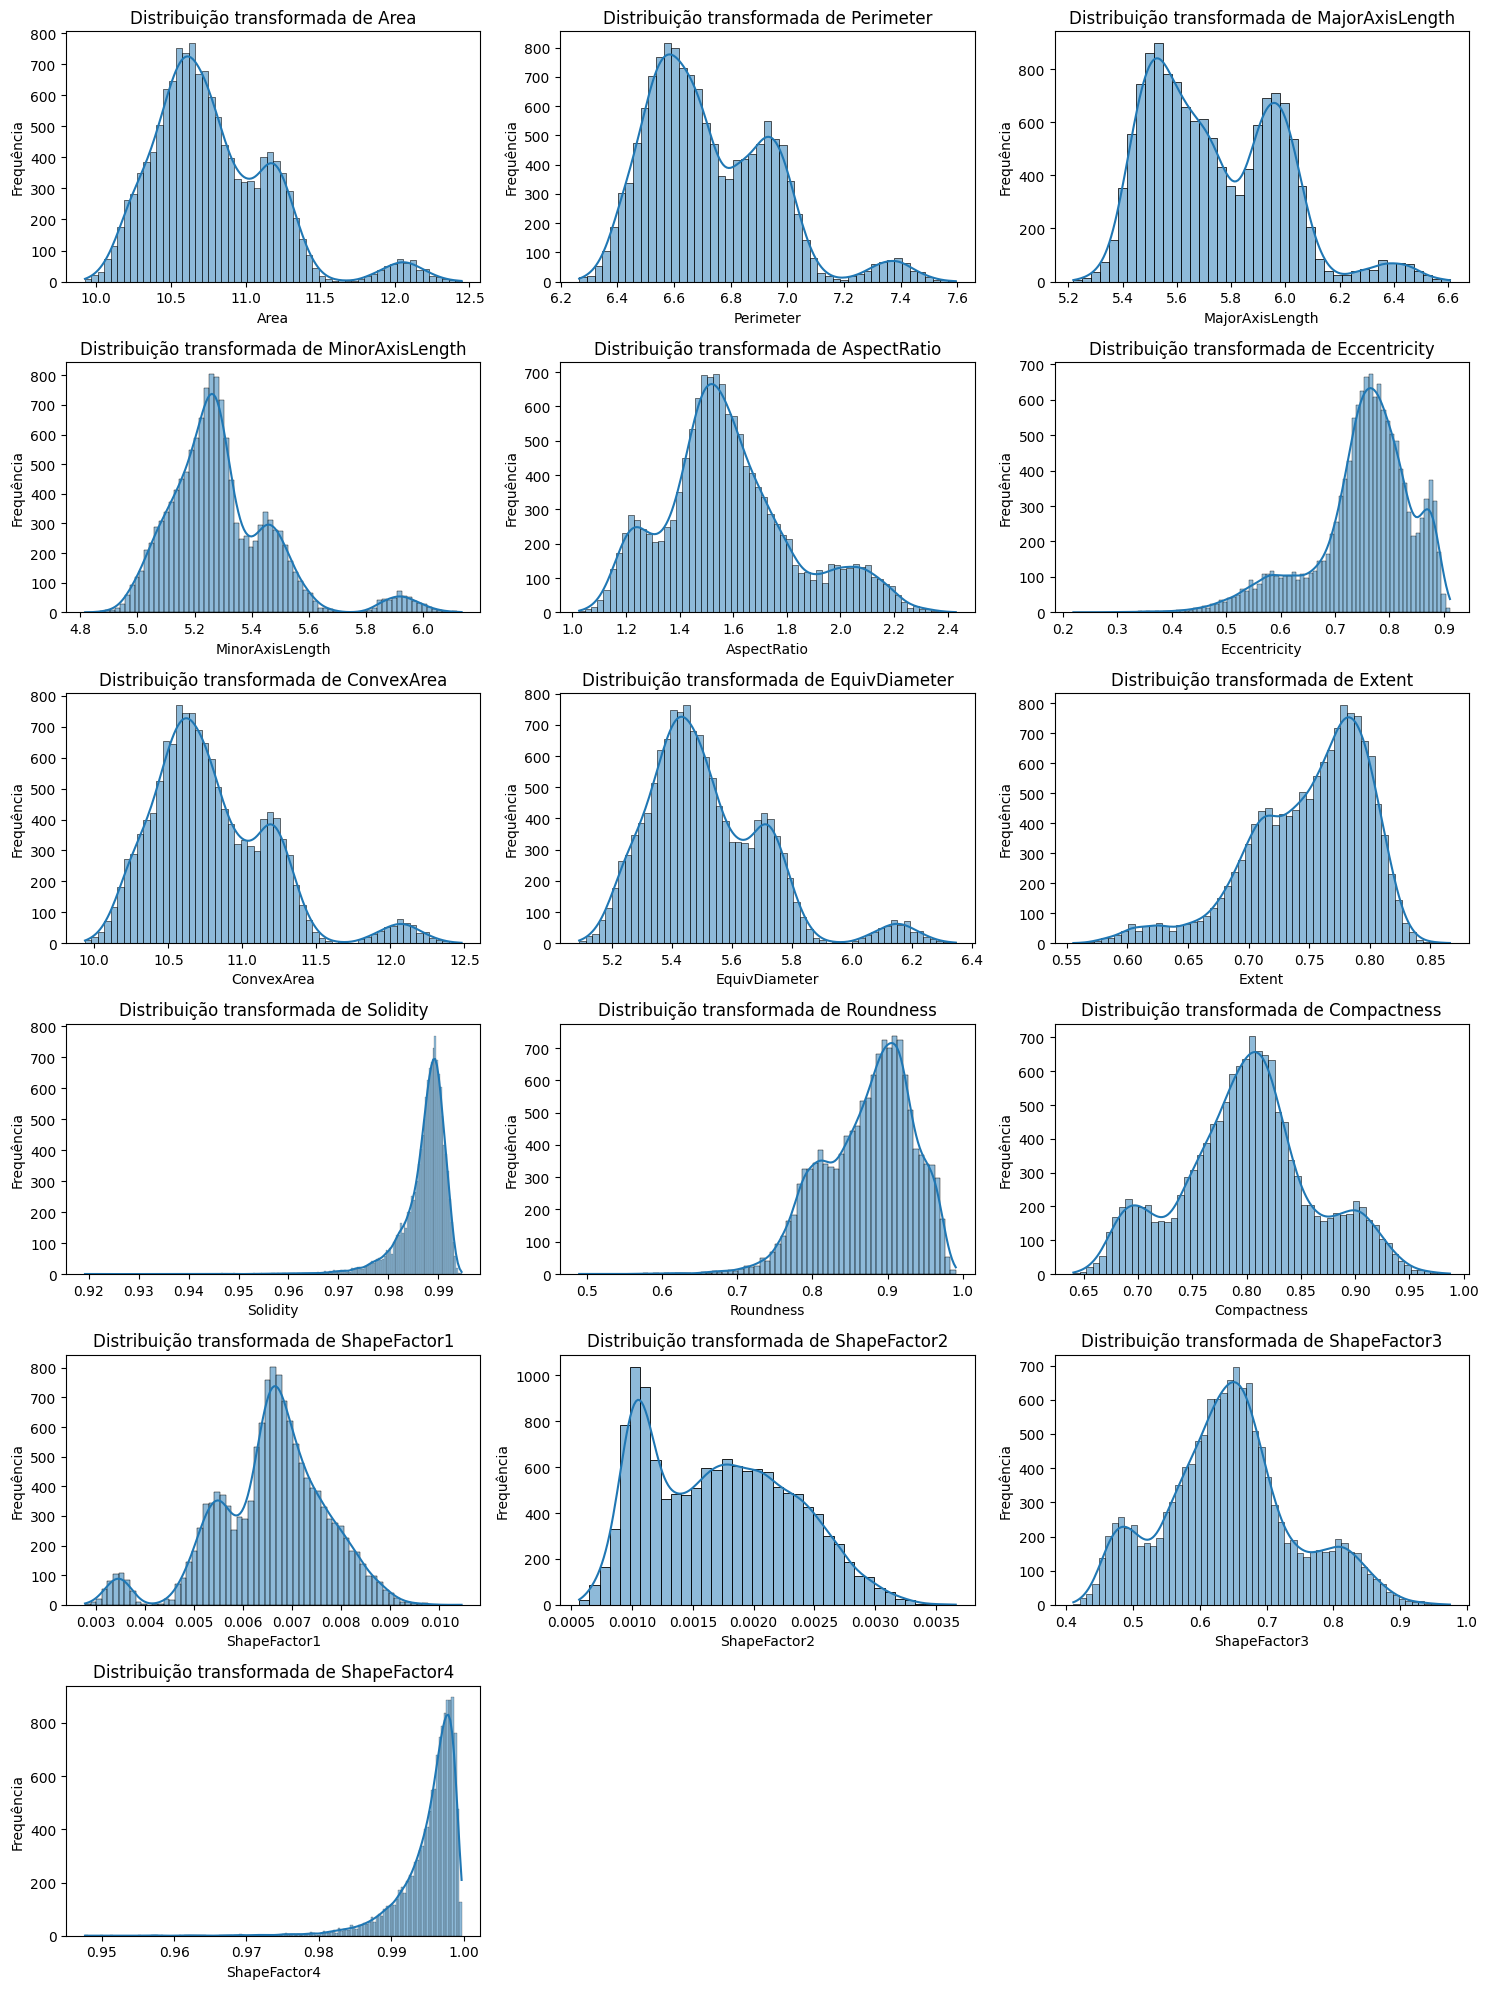

In [ ]:
import numpy as np

numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

skewness = df[numerical_cols].skew()

print("Skewness original:")
print(skewness.sort_values())

limiar = 1.0
cols_log = skewness[skewness > limiar].index.tolist()

print("\nColunas que receberão log1p:")
print(cols_log)

# df_transformado = df.copy()

# for col in cols_log:
#     df_transformado[col] = np.log1p(df_transformado[col])

for col in cols_log:
  df[col] = np.log1p(df[col])

plt.figure(figsize=(15, 20))

n_cols = 3
n_rows = math.ceil(len(numerical_cols) / n_cols)

for i, col in enumerate(numerical_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    # sns.histplot(df_transformado[col], kde=True)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribuição transformada de {col}')
    plt.xlabel(col)
    plt.ylabel('Frequência')

print('\nHistograma após aplicar log apenas nas features com assimetria positiva forte:')
plt.tight_layout()
plt.show()

5. Quais features apresentam distribuição assimétrica com cauda longa? **Se tratando apenas dos valores positivos, são elas: Area, MinorAxisLength, ConvexArea e EquivDiameter.**
6. A transformação log alterou visivelmente a distribuição? Como isso pode beneficiar o treinamento? **Ajudou e muito, essa transformação faz com que os valores discrepantes (outliers) não distorçam o aprendizado da rede, além de que graças a transformação elas aprimoram a capacidade de modelar as relações não lineares e complexas.**


# 1.4 Análise de correlação de Pearson

Matriz de correlação de Pearson:


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRatio,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,Roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
Area,1.000000,0.990651,0.955939,0.929900,0.355168,0.357282,0.999938,1.000000,0.001175,-0.254718,-0.497278,-0.375320,-0.912291,-0.764657,-0.376404,-0.415008
Perimeter,0.990651,1.000000,0.975330,0.885891,0.442488,0.436383,0.991462,0.990626,-0.052619,-0.328124,-0.610771,-0.460572,-0.869733,-0.818707,-0.460639,-0.451736
MajorAxisLength,0.955939,0.975330,1.000000,0.781100,0.612188,0.602208,0.956620,0.955897,-0.112916,-0.307956,-0.660584,-0.630469,-0.760968,-0.913572,-0.630129,-0.500531
MinorAxisLength,0.929900,0.885891,0.781100,1.000000,-0.011507,0.005826,0.929054,0.929953,0.143561,-0.168146,-0.231525,-0.009119,-0.987290,-0.482314,-0.011878,-0.272236
AspectRatio,0.355168,0.442488,0.612188,-0.011507,1.000000,0.924293,0.357182,0.355024,-0.370184,-0.267754,-0.766979,-0.987687,0.024593,-0.837841,-0.978592,-0.449264
Eccentricity,0.357282,0.436383,0.602208,0.005826,0.924293,1.000000,0.359630,0.357187,-0.319362,-0.297592,-0.722272,-0.970313,0.019920,-0.860141,-0.981058,-0.449354
ConvexArea,0.999938,0.991462,0.956620,0.929054,0.357182,0.359630,1.000000,0.999937,-0.001028,-0.265486,-0.502774,-0.377688,-0.911327,-0.766317,-0.378813,-0.421870
EquivDiameter,1.000000,0.990626,0.955897,0.929953,0.355024,0.357187,0.999937,1.000000,0.001265,-0.254676,-0.497118,-0.375193,-0.912262,-0.764528,-0.376283,-0.414965
Extent,0.001175,-0.052619,-0.112916,0.143561,-0.370184,-0.319362,-0.001028,0.001265,1.000000,0.191389,0.344411,0.354212,-0.141616,0.237956,0.347624,0.148502
Solidity,-0.254718,-0.328124,-0.307956,-0.168146,-0.267754,-0.297592,-0.265486,-0.254676,0.191389,1.000000,0.607150,0.303766,0.153388,0.343559,0.307662,0.702163


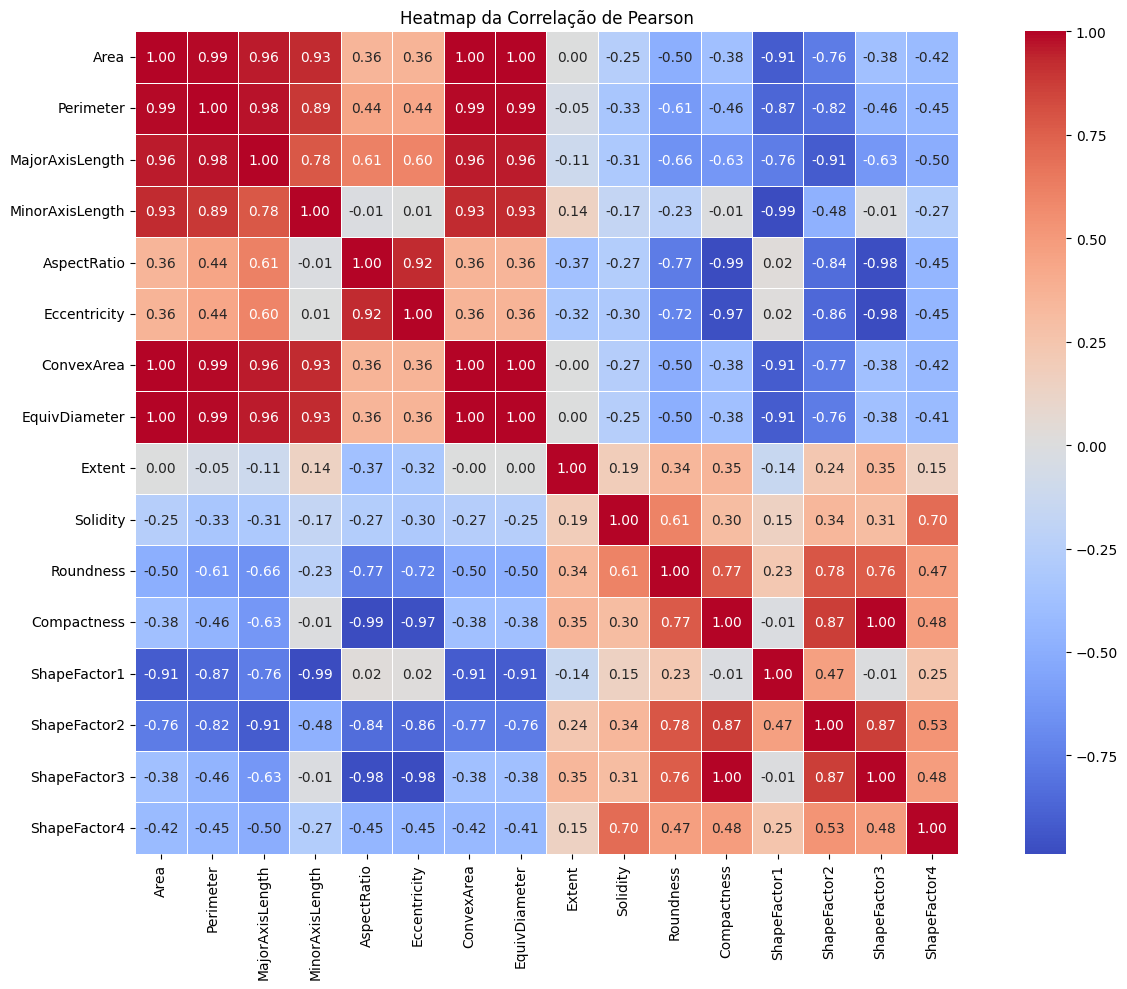

In [ ]:
numerical_df = df.select_dtypes(include=['int64', 'float64'])

corr_matrix = numerical_df.corr(method='pearson')

print("Matriz de correlação de Pearson:")
display(corr_matrix)

plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True,
    linewidths=0.5
)

plt.title("Heatmap da Correlação de Pearson")
plt.tight_layout()
plt.show()

7. Identifique pelo menos 3 pares de features com correlação acima de 0.90. **São eles: Compactness e ShapeFactor3, Area e EquivDiameter, Perimeter e MajorAxisLength.**
8. O que é multicolinearidade? Features muito correlacionadas trazem informação nova ou são redundantes? Features muito correlacionadas são obrigadas a serem removidas do dataset de treinamento? É possível que ao não removê-las ainda sim obtenhamos bons resultados? **Multicolinearidade é quando duas ou mais features possuem forte relação colinear entre si. Essas informações costumam acabar sendo redundantes e não necessariamente novas, mas isso não quer dizer que elas necessariamente precisam ser removidas para melhorar o treinamento de uma rede neural, visto que a presença delas normalmente deve ser definida com base em testes para identificar se estão agregando ou só tornando a rede neural mais complexa/pesada desnecessariamente.**

# 1.5 Boxplots por classe

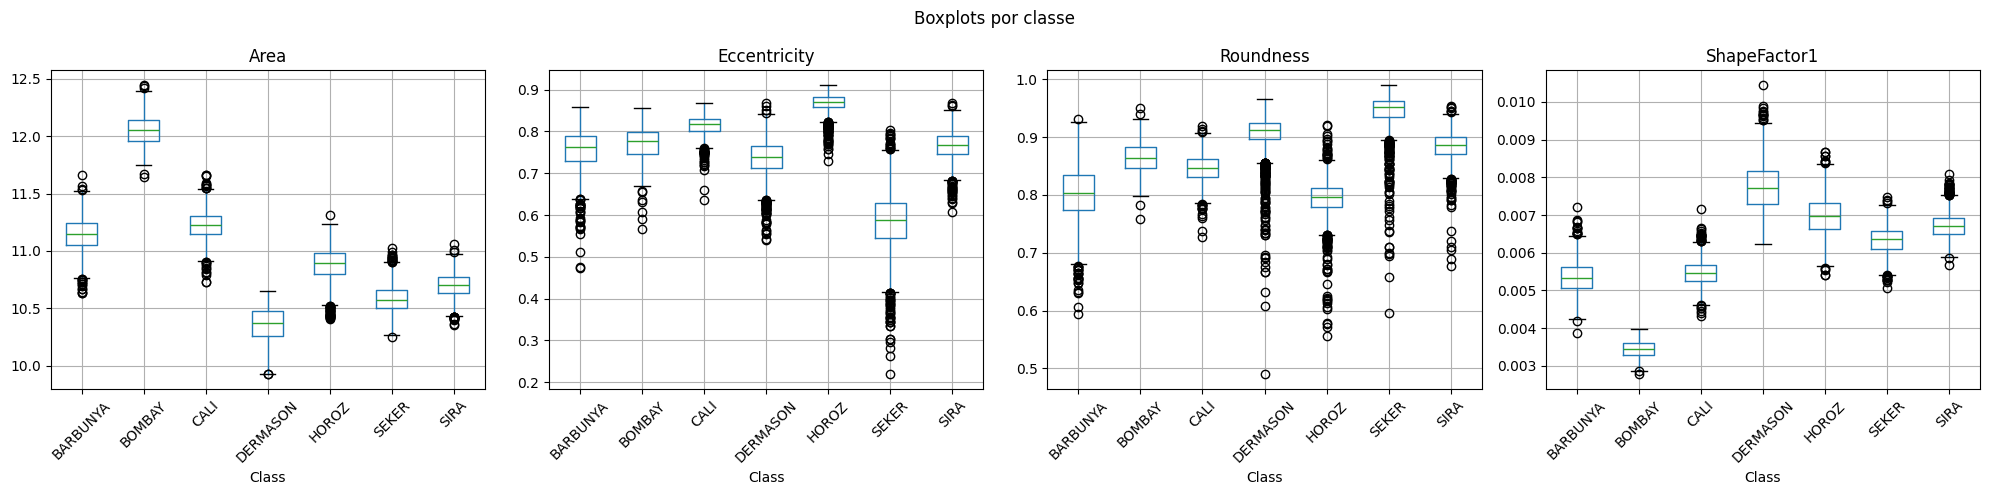

In [ ]:
boxplot_cols = ['Area', 'Eccentricity', 'Roundness', 'ShapeFactor1']

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for i, col in enumerate(boxplot_cols):
    df.boxplot(column=col, by='Class', ax=axes[i])
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=45)

plt.suptitle('Boxplots por classe')
plt.tight_layout()
plt.show()

9. Com base no heatmap e nos boxplots, quais features você selecionaria para treinar o modelo? **Com base neles, eu usaria a Area, Eccentricity, Extent, Solidity, Roundness e o ShapeFactor4.**
10. Quais features melhor separam as classes visualmente? **Com base nos gráficos boxplot, pode-se dizer que a Area e o ShapeFactor1 são as features que melhor separam visualmente as classes, pois apresentam maior afastamento entre as medianas das classes e, em vários casos, menor sobreposição entre as distribuições.**
11. Quais classes apresentam maior sobreposição? Você espera que o modelo erre mais nessas classes? **CALI, SIRA E BARBUNYA são as que mais parecem ter sobreposição nos gráficos. É esperado que o  modelo erre mais se tratando delas, justamente devido aos valores serem mais próximos entre si (dependendo da feature).**


# 2.1 Codificação da variável alvo

In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
df['Class'] = label_encoder.fit_transform(df['Class'])

print('Class original -> encoded')
for i, class_name in enumerate(label_encoder.classes_):
    print(f'{class_name}: {i}')

Class original -> encoded
BARBUNYA: 0
BOMBAY: 1
CALI: 2
DERMASON: 3
HOROZ: 4
SEKER: 5
SIRA: 6


# 2.2 Normalização das features

12. Por que não podemos ajustar o scaler nos dados de teste? **Para não que não ocorra um vazamento de dados, os dados de testes não podem ser ajustados (garantir que serão tratados como dados novos).**
13. O que aconteceria com as predições em produção se o scaler usado no treinamento fosse   diferente do aplicado nas novas entradas? **O modelo traria as respostas erradas, visto que as métricas usadas nos testes são diferentes das que estão sendo usadas em produção.**


# 2.3 Tratamento do desbalanceamento com class_weight

14. A classe BOMBAY recebeu o maior ou menor peso? Por que? **Recebeu maior peso, devido ao baixo número de amostras.**
15. O que acontece quando o modelo erra uma amostra de BOMBAY vs uma de DERMASON com esses pesos? **Os erros da classe BOMBAY possuem penalização maior no cálculo da LOSS, diferente dos erros de DERMASON (que possui muitas amostras).**


# 2.4 Divisão treino / validação / teste

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop(columns='Class')
y = df['Class']

X_temporario, X_teste, y_temporario, y_teste = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


X_treino, X_validacao, y_treino, y_validacao = train_test_split(
    X_temporario, y_temporario,
    test_size=0.25,  # 25% de 80% = 20% do total
    random_state=42,
    stratify=y_temporario
)

scaler = StandardScaler()
X_treino_escalado = scaler.fit_transform(X_treino)
X_validacao_escalado = scaler.transform(X_validacao)
X_teste_escalado = scaler.transform(X_teste)

print('Treino:', X_treino_escalado.shape, y_treino.shape)
print('Validação:', X_validacao_escalado.shape, y_validacao.shape)
print('Teste:', X_teste_escalado.shape, y_teste.shape)

Treino: (8166, 16) (8166,)
Validação: (2722, 16) (2722,)
Teste: (2723, 16) (2723,)


16. Por que o parâmetro stratify e importante neste dataset especificamente? **Justamente devido ao baixo número de amostras de determinadas classes é necessário garantir que todas possuam a mesma proporção nos conjuntos de treino, validação e teste.**
17. Por que os dados de teste só devem ser usados na avaliação final, e não para ajustar a arquitetura ou os hiperparametros? **Para que não ocorra um vazamento de dados. É preciso garantir que a rede não demonstre ter aprendido algo, quando na verdade apenas decorou as respostas (não pode existir overfitting durante o treinamento).**


# 3.2 Arquitetura da rede

In [ ]:
from tensorflow import keras
from keras import layers

num_classes = X_treino.shape[1]

modelA = keras.Sequential([
    layers.Input(shape=(num_classes,)),

    layers.Dense(64, activation='relu', kernel_initializer='he_normal'),
    layers.Dropout(0.3),

    layers.Dense(32, activation='relu', kernel_initializer='he_normal'),
    layers.Dropout(0.2),

    layers.Dense(7, activation='softmax')
])

modelA.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

modelB = keras.Sequential([
    layers.Input(shape=(num_classes,)),
    layers.Dense(128, activation='relu', kernel_initializer='he_normal'),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu', kernel_initializer='he_normal'),
    layers.Dropout(0.2),
    layers.Dense(32, activation='relu', kernel_initializer='he_normal'),
    layers.Dropout(0.3),
    layers.Dense(7, activation='softmax')
])

modelB.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

modelA.summary()
modelB.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,399 (13.28 KB)

 Trainable params: 3,399 (13.28 KB)

 Non-trainable params: 0 (0.00 B)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │         2,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,743 (49.78 KB)

 Trainable params: 12,743 (49.78 KB)

 Non-trainable params: 0 (0.00 B)

OBS: Criamos dois modelos de treino para obter diferentes resultados (modelA e modelB), usamos um contendo 2 camadas ocultas e um contendo 3 (adicionando mais neurônios nessa terceira camada oculta), respectivamente.

18. Por que a camada de saída usa softmax com 7 neurônios? **Porque como o resultado não é binário, o softmax deve ser usado para trazer a probablidade (soma dá 1) da entrada X serem a classe Y em meio as outras 6 existentes.**
19. Por que a função de perda é sparse_categorical_crossentropy e nao binary_crossentropy? **Porque a binary_crossentropy abrange apenas dois tipos de resultados, ou seja, binários (o problema traz 7 no total).**
20. O Dropout é aplicado na camada de saída? **O Dropout é aplicado nas camadas ocultas para reduzir overfitting. Na camada de saída ele não é usado, pois prejudicaria a predição final das classes.**


# 3.3 Experimentos

In [ ]:
from tensorflow import keras
from keras import layers, initializers
from sklearn.metrics import accuracy_score, f1_score, classification_report
from keras.callbacks import ModelCheckpoint

def criar_modelo(quantidade_features, quantidade_classes, params):
    modelo = keras.Sequential()
    modelo.add(layers.Input(shape=(quantidade_features,)))

    unidades = params.get('units', [64, 32])
    dropouts = params.get('dropout', [0.3, 0.2])
    ativacao = params.get('activation', 'relu')
    nome_inicializador = params.get('initializer', 'he_normal')
    taxa_aprendizado = params.get('learning_rate', 0.001)

    if nome_inicializador == 'he_normal':
        inicializador = 'he_normal'
    elif nome_inicializador == 'random_normal':
        inicializador = initializers.RandomNormal(mean=0.0, stddev=0.05)
    else:
        inicializador = nome_inicializador

    for i, unidade in enumerate(unidades):
        modelo.add(
            layers.Dense(
                unidade,
                activation=ativacao,
                kernel_initializer=inicializador
            )
        )

        if i < len(dropouts) and dropouts[i] > 0:
            modelo.add(layers.Dropout(dropouts[i]))

    modelo.add(layers.Dense(quantidade_classes, activation='softmax'))

    otimizador = keras.optimizers.Adam(learning_rate=taxa_aprendizado)

    modelo.compile(
        optimizer=otimizador,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return modelo


def rodar_experimento(
    nome_experimento,
    X_treino, y_treino,
    X_validacao, y_validacao,
    X_teste, y_teste,
    params,
    class_weights_dict=None,
    best_model: bool=False
):
    quantidade_features = X_treino.shape[1]
    quantidade_classes = len(np.unique(y_treino))

    modelo = criar_modelo(quantidade_features, quantidade_classes, params)

    early_stopping = keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=params.get('patience', 10),
        restore_best_weights=True
    )

    callbacks = [early_stopping]

    if best_model:
        model_checkpoint = ModelCheckpoint(
            filepath="best_model.keras",
            save_best_only=True,
            monitor="val_loss",
            mode="min" # salva o modelo quando o loss começa a decair
        )
        callbacks.append(model_checkpoint)

    argumentos_fit = {
        'x': X_treino,
        'y': y_treino,
        'validation_data': (X_validacao, y_validacao),
        'epochs': params.get('epochs', 100),
        'batch_size': params.get('batch_size', 32),
        'callbacks': callbacks,
        'verbose': params.get('verbose', 1)
    }

    if params.get('use_class_weight', False) and class_weights_dict is not None:
        argumentos_fit['class_weight'] = class_weights_dict

    history = modelo.fit(**argumentos_fit)

    y_probabilidades = modelo.predict(X_teste, verbose=0)
    y_pred = np.argmax(y_probabilidades, axis=1)

    acuracia = accuracy_score(y_teste, y_pred)
    f1_macro = f1_score(y_teste, y_pred, average='macro')
    relatorio = classification_report(y_teste, y_pred)

    resultados = {
        'experimento': nome_experimento,
        'accuracy': acuracia,
        'f1_macro': f1_macro,
        'epocas_treinadas': len(history.history['loss']),
        'params': params,
        'classification_report': relatorio,
        'history': history.history,
        'model': modelo,
        'y_pred': y_pred,
        'quantidade_features': quantidade_features
    }

    print(f'\n===== {nome_experimento} =====')
    print(f'Accuracy: {acuracia:.4f}')
    print(f'F1-macro: {f1_macro:.4f}')
    print(f'Épocas treinadas: {len(history.history["loss"])}')
    print('\nClassification Report:')
    print(relatorio)

    return resultados

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

features_selecionadas = [
    'Area',
    'Eccentricity',
    'Extent',
    'Roundness',
    'Solidity',
    'ShapeFactor4'
]

def plotar_curvas(historico, titulo='Curvas de aprendizado'):
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(historico['loss'], label='Treino')
    plt.plot(historico['val_loss'], label='Validação')
    plt.title(f'{titulo} - Loss')
    plt.xlabel('Épocas')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(historico['accuracy'], label='Treino')
    plt.plot(historico['val_accuracy'], label='Validação')
    plt.title(f'{titulo} - Accuracy')
    plt.xlabel('Épocas')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()


def resumir_resultados(lista_resultados):
    linhas = []

    for resultado in lista_resultados:
        linhas.append({
            'Experimento': resultado['experimento'],
            'Accuracy': round(resultado['accuracy'], 4),
            'F1-macro': round(resultado['f1_macro'], 4),
            'Épocas': resultado['epocas_treinadas'],
            'Units': str(resultado['params'].get('units')),
            'Dropout': str(resultado['params'].get('dropout')),
            'Initializer': resultado['params'].get('initializer'),
            'Batch size': resultado['params'].get('batch_size'),
            'Learning rate': resultado['params'].get('learning_rate'),
            'Class weight': resultado['params'].get('use_class_weight'),
            'Features': resultado['quantidade_features']
        })

    return pd.DataFrame(linhas)

## Experimento A - Sem Dropout


===== Experimento A - Sem Dropout =====
Accuracy: 0.9240
F1-macro: 0.9341
Épocas treinadas: 34

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.90      0.92       265
           1       1.00      0.99      1.00       104
           2       0.92      0.95      0.94       326
           3       0.92      0.93      0.92       709
           4       0.97      0.94      0.95       386
           5       0.94      0.95      0.95       406
           6       0.87      0.87      0.87       527

    accuracy                           0.92      2723
   macro avg       0.94      0.93      0.93      2723
weighted avg       0.92      0.92      0.92      2723



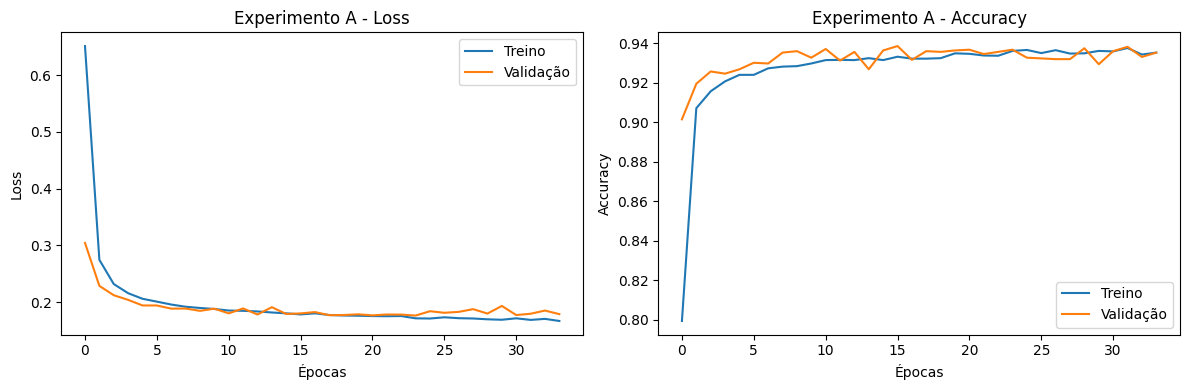

In [ ]:
params_A = {
    'units': [64, 32],
    'dropout': [0.0, 0.0],
    'initializer': 'he_normal',
    'batch_size': 32,
    'epochs': 100,
    'patience': 10,
    'learning_rate': 0.001,
    'use_class_weight': False,
    'verbose': 0
}

resultado_A = rodar_experimento(
    nome_experimento='Experimento A - Sem Dropout',
    X_treino=X_treino_escalado, y_treino=y_treino,
    X_validacao=X_validacao_escalado, y_validacao=y_validacao,
    X_teste=X_teste_escalado, y_teste=y_teste,
    params=params_A
)

plotar_curvas(resultado_A['history'], 'Experimento A')

## Experimento A2 - Com Dropout


===== Experimento A2 - Com Dropout =====
Accuracy: 0.9225
F1-macro: 0.9334
Épocas treinadas: 59

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.89      0.92       265
           1       1.00      0.99      1.00       104
           2       0.91      0.95      0.93       326
           3       0.90      0.93      0.92       709
           4       0.96      0.96      0.96       386
           5       0.94      0.96      0.95       406
           6       0.89      0.85      0.87       527

    accuracy                           0.92      2723
   macro avg       0.94      0.93      0.93      2723
weighted avg       0.92      0.92      0.92      2723



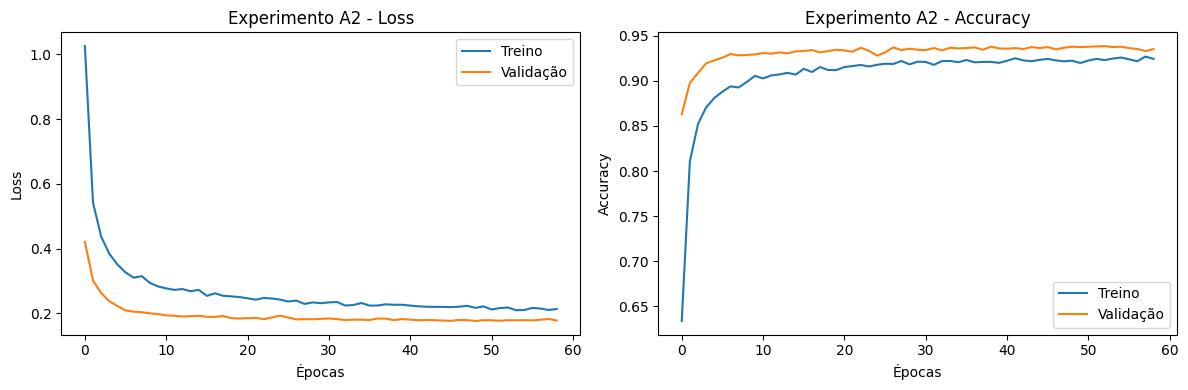

In [ ]:
params_A2 = {
    'units': [64, 32],
    'dropout': [0.3, 0.2],
    'initializer': 'he_normal',
    'batch_size': 32,
    'epochs': 100,
    'patience': 10,
    'learning_rate': 0.001,
    'use_class_weight': False,
    'verbose': 0
}

resultado_A2 = rodar_experimento(
    nome_experimento='Experimento A2 - Com Dropout',
    X_treino=X_treino_escalado, y_treino=y_treino,
    X_validacao=X_validacao_escalado, y_validacao=y_validacao,
    X_teste=X_teste_escalado, y_teste=y_teste,
    params=params_A2
)

plotar_curvas(resultado_A2['history'], 'Experimento A2')

## Experimento B - Com class_weight()

In [ ]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_treino)

pesos_classes = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_treino
)

class_weights_dict = dict(zip(classes, pesos_classes))

print('Pesos das classes:')
print(class_weights_dict)

Pesos das classes:
{np.int64(0): np.float64(1.471086290758422), np.int64(1): np.float64(3.727065267001369), np.int64(2): np.float64(1.1928133216476775), np.int64(3): np.float64(0.5482008592910849), np.int64(4): np.float64(1.0091448344043499), np.int64(5): np.float64(0.9593515037593985), np.int64(6): np.float64(0.7374029257720788)}



===== Experimento B - Class Weight =====
Accuracy: 0.9207
F1-macro: 0.9325
Épocas treinadas: 49

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.91      0.92       265
           1       1.00      1.00      1.00       104
           2       0.92      0.94      0.93       326
           3       0.92      0.91      0.91       709
           4       0.96      0.95      0.95       386
           5       0.94      0.96      0.95       406
           6       0.87      0.86      0.86       527

    accuracy                           0.92      2723
   macro avg       0.93      0.93      0.93      2723
weighted avg       0.92      0.92      0.92      2723



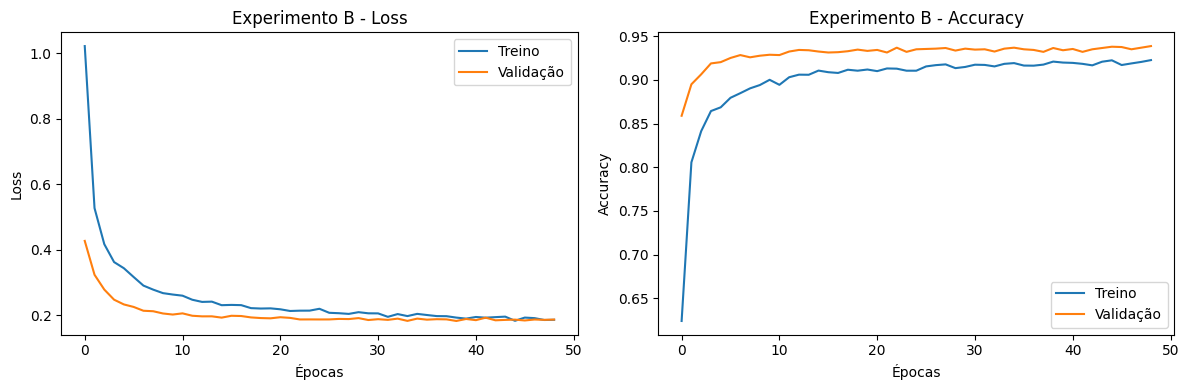

In [ ]:
params_B = {
    'units': [64, 32],
    'dropout': [0.3, 0.2],
    'initializer': 'he_normal',
    'batch_size': 32,
    'epochs': 100,
    'patience': 10,
    'learning_rate': 0.001,
    'use_class_weight': True,
    'verbose': 0
}

resultado_B = rodar_experimento(
    nome_experimento='Experimento B - Class Weight',
    X_treino=X_treino_escalado, y_treino=y_treino,
    X_validacao=X_validacao_escalado, y_validacao=y_validacao,
    X_teste=X_teste_escalado, y_teste=y_teste,
    params=params_B,
    class_weights_dict=class_weights_dict
)

plotar_curvas(resultado_B['history'], 'Experimento B')

## Experimento C - Arquitetura Maior


===== Experimento C - Arquitetura Maior =====
Accuracy: 0.9236
F1-macro: 0.9344
Épocas treinadas: 29

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.90      0.92       265
           1       1.00      0.99      1.00       104
           2       0.94      0.94      0.94       326
           3       0.91      0.93      0.92       709
           4       0.96      0.95      0.96       386
           5       0.94      0.96      0.95       406
           6       0.88      0.85      0.87       527

    accuracy                           0.92      2723
   macro avg       0.94      0.93      0.93      2723
weighted avg       0.92      0.92      0.92      2723



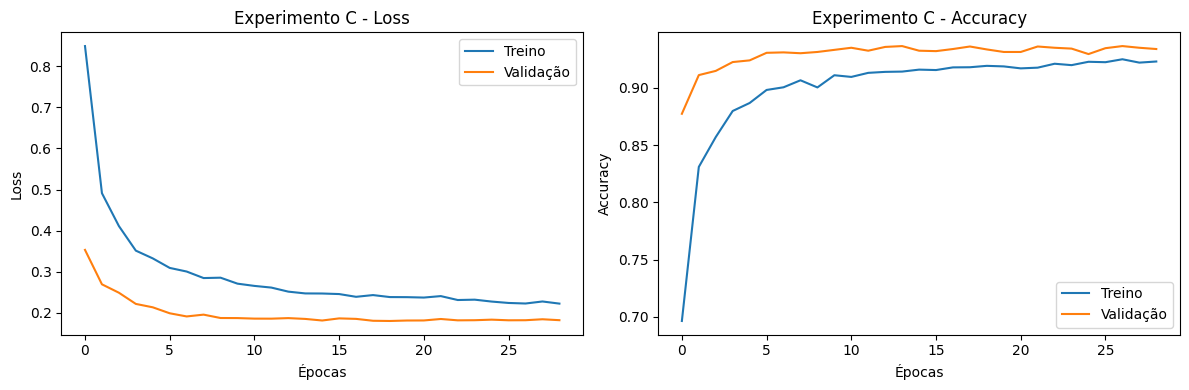

In [ ]:
params_C = {
    'units': [128, 64, 32],
    'dropout': [0.3, 0.2, 0.2],
    'initializer': 'he_normal',
    'batch_size': 32,
    'epochs': 100,
    'patience': 10,
    'learning_rate': 0.001,
    'use_class_weight': False,
    'verbose': 0
}

resultado_C = rodar_experimento(
    nome_experimento='Experimento C - Arquitetura Maior',
    X_treino=X_treino_escalado, y_treino=y_treino,
    X_validacao=X_validacao_escalado, y_validacao=y_validacao,
    X_teste=X_teste_escalado, y_teste=y_teste,
    params=params_C
)

plotar_curvas(resultado_C['history'], 'Experimento C')

## Experimento D - Inicializador diferente (he_normal e RandomNormal)


===== Experimento D - RandomNormal =====
Accuracy: 0.9199
F1-macro: 0.9309
Épocas treinadas: 32

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.90      0.92       265
           1       0.99      1.00      1.00       104
           2       0.92      0.94      0.93       326
           3       0.90      0.93      0.92       709
           4       0.96      0.95      0.96       386
           5       0.94      0.95      0.95       406
           6       0.88      0.85      0.86       527

    accuracy                           0.92      2723
   macro avg       0.93      0.93      0.93      2723
weighted avg       0.92      0.92      0.92      2723



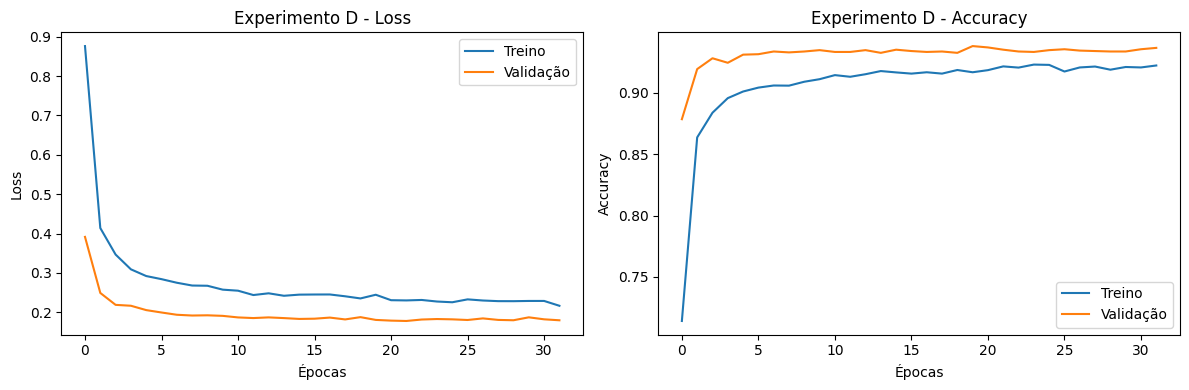

In [ ]:
params_D = {
    'units': [64, 32],
    'dropout': [0.3, 0.2],
    'initializer': 'random_normal',
    'batch_size': 32,
    'epochs': 100,
    'patience': 10,
    'learning_rate': 0.001,
    'use_class_weight': False,
    'verbose': 0
}

resultado_D = rodar_experimento(
    nome_experimento='Experimento D - RandomNormal',
    X_treino=X_treino_escalado, y_treino=y_treino,
    X_validacao=X_validacao_escalado, y_validacao=y_validacao,
    X_teste=X_teste_escalado, y_teste=y_teste,
    params=params_D
)

plotar_curvas(resultado_D['history'], 'Experimento D')

## Experimento E - Features Selecionadas na AED


===== Experimento E - Features Selecionadas =====
Accuracy: 0.9210
F1-macro: 0.9326
Épocas treinadas: 50

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.89      0.91       265
           1       1.00      1.00      1.00       104
           2       0.93      0.94      0.94       326
           3       0.90      0.93      0.91       709
           4       0.96      0.95      0.96       386
           5       0.93      0.96      0.94       406
           6       0.88      0.84      0.86       527

    accuracy                           0.92      2723
   macro avg       0.93      0.93      0.93      2723
weighted avg       0.92      0.92      0.92      2723



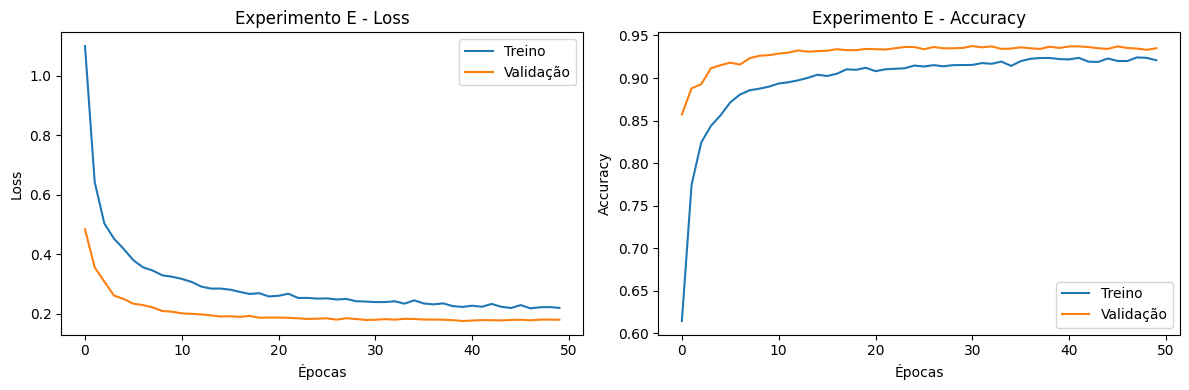

In [ ]:
X_treino_sel = X_treino[features_selecionadas].copy()
X_validacao_sel = X_validacao[features_selecionadas].copy()
X_teste_sel = X_teste[features_selecionadas].copy()

scaler_sel = StandardScaler()
X_treino_sel_escalado = scaler_sel.fit_transform(X_treino_sel)
X_validacao_sel_escalado = scaler_sel.transform(X_validacao_sel)
X_teste_sel_escalado = scaler_sel.transform(X_teste_sel)

params_E = {
    'units': [64, 32],
    'dropout': [0.3, 0.2],
    'initializer': 'he_normal',
    'batch_size': 32,
    'epochs': 100,
    'patience': 10,
    'learning_rate': 0.001,
    'use_class_weight': False,
    'verbose': 0
}

resultado_E = rodar_experimento(
    nome_experimento='Experimento E - Features Selecionadas',
    X_treino=X_treino_sel_escalado, y_treino=y_treino,
    X_validacao=X_validacao_sel_escalado, y_validacao=y_validacao,
    X_teste=X_teste_sel_escalado, y_teste=y_teste,
    params=params_E
)

plotar_curvas(resultado_E['history'], 'Experimento E')

## Experimento F - Melhor Configuração


===== Experimento F - Melhor Configuração =====
Accuracy: 0.9266
F1-macro: 0.9367
Épocas treinadas: 30

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.92      0.92       265
           1       0.99      0.99      0.99       104
           2       0.95      0.94      0.94       326
           3       0.91      0.93      0.92       709
           4       0.97      0.95      0.96       386
           5       0.95      0.95      0.95       406
           6       0.88      0.87      0.87       527

    accuracy                           0.93      2723
   macro avg       0.94      0.94      0.94      2723
weighted avg       0.93      0.93      0.93      2723



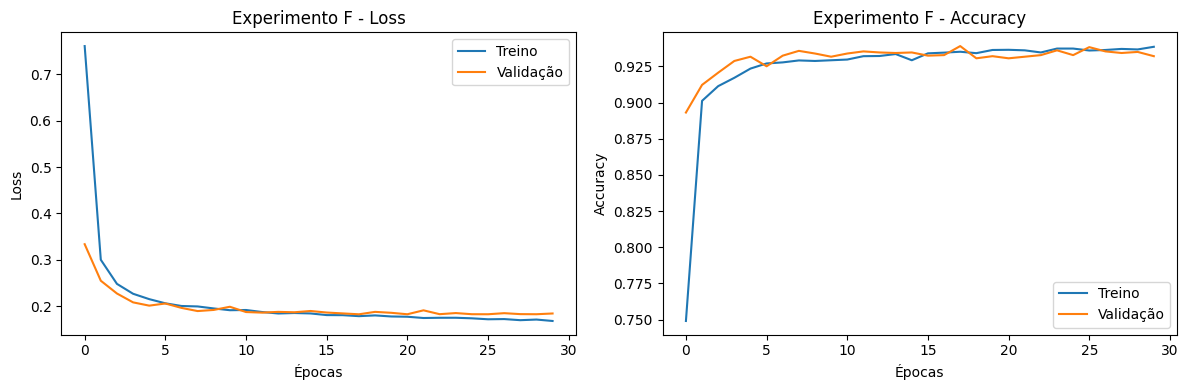

In [ ]:
params_F = {
    'units': [64, 32],
    'dropout': [],
    'initializer': 'he_normal',
    'batch_size': 32,
    'epochs': 120,
    'patience': 12,
    'learning_rate': 0.001,
    'use_class_weight': False,
    'verbose': 0
}

resultado_F = rodar_experimento(
    nome_experimento='Experimento F - Melhor Configuração',
    X_treino=X_treino_sel_escalado, y_treino=y_treino,
    X_validacao=X_validacao_sel_escalado, y_validacao=y_validacao,
    X_teste=X_teste_sel_escalado, y_teste=y_teste,
    params=params_F,
    best_model=True
)

plotar_curvas(resultado_F['history'], 'Experimento F')

In [ ]:
todos_resultados = [
    resultado_A,
    resultado_A2,
    resultado_B,
    resultado_C,
    resultado_D,
    resultado_E,
    resultado_F
]

tabela_resultados = resumir_resultados(todos_resultados)
display(tabela_resultados)

melhor_resultado = max(todos_resultados, key=lambda resultado: resultado['f1_macro'])

print('\nMelhor experimento com base no F1-macro:')
print(melhor_resultado['experimento'])
print(f'Accuracy: {melhor_resultado["accuracy"]:.4f}')
print(f'F1-macro: {melhor_resultado["f1_macro"]:.4f}')

,Experimento,Accuracy,F1-macro,Épocas,Units,Dropout,Initializer,Batch size,Learning rate,Class weight,Features
0,Experimento A - Sem Dropout,0.9240,0.9341,34,"[64, 32]","[0.0, 0.0]",he_normal,32,0.001,False,16
1,Experimento A2 - Com Dropout,0.9225,0.9334,59,"[64, 32]","[0.3, 0.2]",he_normal,32,0.001,False,16
2,Experimento B - Class Weight,0.9207,0.9325,49,"[64, 32]","[0.3, 0.2]",he_normal,32,0.001,True,16
3,Experimento C - Arquitetura Maior,0.9236,0.9344,29,"[128, 64, 32]","[0.3, 0.2, 0.2]",he_normal,32,0.001,False,16
4,Experimento D - RandomNormal,0.9199,0.9309,32,"[64, 32]","[0.3, 0.2]",random_normal,32,0.001,False,16
5,Experimento E - Features Selecionadas,0.9210,0.9326,50,"[64, 32]","[0.3, 0.2]",he_normal,32,0.001,False,6
6,Experimento F - Melhor Configuração,0.9266,0.9367,30,"[64, 32]",[],he_normal,32,0.001,False,6



Melhor experimento com base no F1-macro:
Experimento F - Melhor Configuração
Accuracy: 0.9266
F1-macro: 0.9367


## Salvar o Scaler e o Encoder

21. Por que é necessário salvar o scaler junto com o modelo? <br>
R: É necessário salvar o scaler porque o modelo foi treinado com dados transformados por ele (por exemplo, usando média e desvio padrão específicos). Para garantir consistência, novos dados precisam passar exatamente pela mesma transformação. Caso contrário, o modelo receberá entradas em uma escala diferente daquela usada no treinamento, o que pode comprometer a qualidade das predições.

22. O que aconteceria se você aplicasse um scaler diferente na hora de fazer predições em produção versus o scaler usado no treinamento? <br>
R: Aplicar um scaler diferente causaria inconsistência na escala dos dados, pois os parâmetros (como média e variância no caso do StandardScaler) seriam diferentes dos usados no treinamento. Isso faria com que o modelo interpretasse os dados de forma incorreta, podendo gerar predições imprecisas ou totalmente erradas.


In [ ]:
import joblib

In [ ]:
joblib.dump(scaler_sel, 'std_scaler.joblib')

['std_scaler.joblib']

In [ ]:
joblib.dump(label_encoder, 'label_encoder.joblib')

['label_encoder.joblib']

# 4. Avaliação e Análise dos Resultados

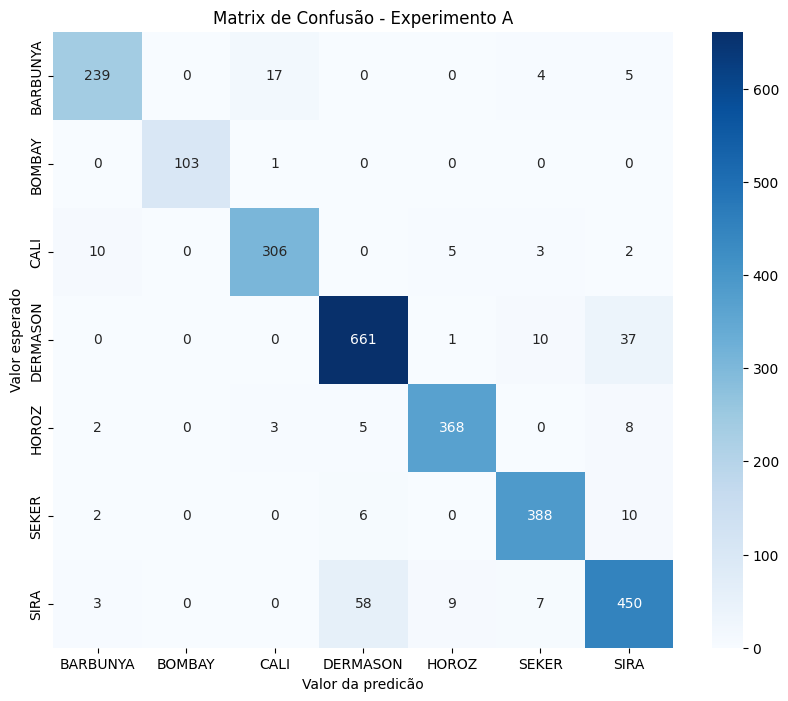

              precision    recall  f1-score   support

           0       0.93      0.90      0.92       265
           1       1.00      0.99      1.00       104
           2       0.94      0.94      0.94       326
           3       0.91      0.93      0.92       709
           4       0.96      0.95      0.96       386
           5       0.94      0.96      0.95       406
           6       0.88      0.85      0.87       527

    accuracy                           0.92      2723
   macro avg       0.94      0.93      0.93      2723
weighted avg       0.92      0.92      0.92      2723



In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

best_model_results = melhor_resultado
y_pred_best_model = best_model_results["y_pred"]

cm = confusion_matrix(y_teste, y_pred_best_model)
class_names = label_encoder.classes_

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Valor da predicão")
plt.ylabel("Valor esperado")
plt.title("Matrix de Confusão - Experimento A")
plt.show()

print(best_model_results["classification_report"])

23. **Qual classe obteve o menor F1-score? Isso era esperado com base nos boxplots da AED?**
    *   Analisando o `Classification Report` do Experimento A (o melhor em F1-macro), a classe com o menor F1-score é **SIRA (F1-score: 0.88)**.
    *   Sim, isso era esperado. Conforme mencionado na pergunta 11, as classes CALI, SIRA e BARBUNYA apresentavam maior sobreposição nos boxplots. A dificuldade em separar visualmente essas classes, especialmente SIRA, sugere que o modelo também teria mais dificuldade em classificá-las corretamente, resultando em um F1-score mais baixo.

23. **Qual classe obteve o menor F1-score? Isso era esperado com base nos boxplots da AED?**

Analisando o Classification Report do Experimento A (o melhor em F1-macro), a classe com o menor F1-score é SIRA (F1-score: 0.88). Isso era esperado porque, as classes CALI, SIRA e BARBUNYA apresentavam maior sobreposição nos boxplots. A dificuldade em separar visualmente essas classes, especialmente SIRA, sugere que o modelo também teria mais dificuldade em classificar corretamente, resultando em um F1-score mais baixo.


**24. Quais classes o modelo confunde com mais frequência? Elas apresentavam sobreposição nos boxplots?**

Analisando a Matrix de Confusão do Experimento A, é possivel observar que:
SIRA (classe 6) é frequentemente confndida com BARBUNYA (classe 0) e DERMASON (classe 3)
BARBUNYA (classe 0) é confundida com SIRA (classe 6)
DERMASON (classe 3) é confundida com SIRA (classe 6) e CALI (classe 2)
As classes SIRA, BARBUNYA e CALI apresentavam maior sobreposição nos boxplots e a matriz de confusão apresenta isto, mostrando que a sobreposição na AED resulta em confusão do modelo durante a classificação.


**25. A classe BOMBAY foi bem classificada? O uso de class_weight alterou seus resultados?**

A classe BOMBAY (classe 1) foi muito bem classificada em todos os experimentos, com F1-score igual ou muito próximo de 1.00, mesmo com poucas amostras. Isso provavelmente acontece porque suas características são bem diferentes das outras classes, o que facilita a identificação pelo modelo.
omparando o Experimento A2 (com Dropout e sem class_weight) e o Experimento B (com Dropout e class_weight), os resultados foram praticamente iguais para essa classe. No A2, o F1-score foi 1.00 (precisão 1.00 e recall 0.99), e no B os valores se mantiveram os mesmos.
Isso mostra que o uso de class_weight não teve impacto na classe BOMBAY, já que o modelo já conseguia classificá-la quase perfeitamente. Ou seja, mesmo sendo uma classe desbalanceada, ela é naturalmente fácil de diferenciar das demais.


**26. Qual classe obteve o menor F1-score? Isso era esperado com base nos boxplots da AED?**

A classe com menor F1-score foi a SIRA (0.88), que era esperado por conta da sobreposição nos boxplots.


**27. Quais classes o modelo confunde com mais frequência? Elas apresentavam sobreposição nos boxplots?**

As classes mais confundidas foram SIRA, BARBUNYA e DERMASON, e elas apresentavam sobreposição nos boxplots.


**28. Há sinais de que o desbalanceamento afetou o aprendizado? O class_weight (Exp. B) corrigiu?**

Há indícios de que o desbalanceamento influenciou o aprendizado. No Experimento A (sem class_weight), a classe SIRA teve F1-score de 0.88 e BARBUNYA de 0.92, enquanto BOMBAY (a mais desbalanceada) teve 1.00 e DERMASON (mais balanceada) ficou com 0.93. Mesmo não sendo as mais desbalanceadas, SIRA e BARBUNYA têm menos amostras que DERMASON e CALI, e apresentaram mais confusão.
Comparando o Experimento A2 (sem class_weight, com dropout) com o Experimento B (com class_weight), as mudanças foram poucas. SIRA manteve F1-score de 0.86 em ambos, sem melhora. BARBUNYA teve uma leve melhora, de 0.91 para 0.92. BOMBAY continuou com desempenho perfeito (1.00).
No geral, o uso de class_weight trouxe apenas um ganho marginal no F1-macro (de 0.9308 para 0.9316). Isso indica que houve uma leve ajuda ao dar mais peso às classes minoritárias, mas não foi suficiente para resolver totalmente o problema, sugerindo que a dificuldade pode estar mais na semelhança entre as classes do que apenas no desbalanceamento.

**29. Qual experimento produziu o melhor F1-macro? Foi o que você esperava antes de rodar?**

De acordo com a tabela de resultados, o Experimento A (sem Dropout) apresentou o melhor F1-macro, com valor de 0.9374. Não era exatamente o esperado porque no geral, seria esperado que modelos com Dropout (para evitar overfitting), com class_weight (para lidar com desbalanceamento) ou até arquiteturas mais complexas tivessem um desempenho melhor. Porém, o resultado mostra que isso nem sempre acontece na prática. Nesse caso, o modelo sem Dropout pode não estar sofrendo muito com overfitting, ou o Dropout usado pode ter sido um pouco forte e acabou prejudicando o aprendizado.

**30. O Dropout (comparando A vs A2) reduziu o overfitting? Como as curvas evidenciam isso?**

Comparando os experimentos A (sem Dropout) e A2 (com Dropout), não há evidências claras de que o Dropout tenha reduzido o overfitting. No Experimento A, as curvas de loss e accuracy de treino e validação são bem próximas, sem grande divergência, e também a perda de validação acompanha a de treino, que indica boa generalização.
No Experimento A2, com Dropout, as curvas também permanecem próximas, mas o desempenho final é um pouco pior. O F1-macro caiu de 0.9374 (A) para 0.9308 (A2), mostrando que o Dropout não trouxe ganho prático nesse caso.
Isso mostra que o modelo original já não sofria com overfitting significativo. Então adicionar Dropout não ajudou e pode até ter atrapalhado um pouco o aprendizado. Provavelmente o modelo já era suficientemente robusto, ou as taxas de Dropout foram um pouco altas para a complexidade do problema.


**31. Remover features correlacionadas (Experimento E) trouxe ganho real?**

Quais classes foram mais afetadas pela redução de features?
Comparando o Experimento A2 (com Dropout e todas as features) com o Experimento E (com Dropout e features selecionadas), houve pouco ganho no desempenho. A acurácia passou de 0.9196 para 0.9221 e o F1-macro de 0.9308 para 0.9338, que indica uma melhora mas muito pouca.
Analisando as classes, a maioria manteve praticamente o mesmo desempenho. SIRA continuou com F1-score de 0.86 e DERMASON com 0.91. Já BARBUNYA apresentou uma leve melhora, passando de 0.91 para 0.92.
Assim, a classe mais beneficiada foi BARBUNYA, enquanto as demais não sofreram impacto significativo. Isso mostra que a seleção de features ajudou a refinar o modelo sem prejudicar sua capacidade de diferenciar as classes.


**32. Justifique a configuração escolhida no Experimento F como sua melhor versão.**

O Experimento F foi definido como a melhor configuração com base nos resultados anteriores. Foi combinado as features selecionadas (do Experimento E, que já havia mostrado um pequeno ganho) e removeu o dropout, voltando com uma ideia parecida com o Experimento A que teve o melhor desempenho sem essa técnica. Parâmetros como o inicializador he_normal, batch size 32 e learning rate de 0.001 foram mantidos por já apresentarem bons resultados. Além disso, a paciência e o número de épocas foram aumentados para dar mais tempo ao modelo para convergir.
A ideia foi juntar features mais relevantes com um modelo sem dropout, já que, neste caso, o dropout pareceu mais atrapalhar do que ajudar. Como os modelos sem dropout tiveram melhor F1-macro, essa escolha fez mais sentido. E o resultado foi um F1-macro de 0.9387, o melhor entre todos os experimentos, mostrando que essa configuração conseguiu extrair o melhor desempenho do modelo para esse dataset.


**33. Qual experimento produziu o melhor F1-macro? Foi o que você esperava antes de rodar?**

O experimento F produziu melhor F1-macro de 0.9387. Isso não era exatamente o esperado porque antes de reproduzir os testes, seria razoável imaginar que técnicas como dropout, uso de class_weight ou modelos mais complexos trariam os melhores resultados. Porém, ao longo dos experimentos, ficou claro que essas estratégias nem sempre ajudaram e, em alguns casos, até reduziram levemente o desempenho.

**34. O Dropout alto (se testado) melhorou ou piorou o resultado? Como isso se reflete nas curvas?**

Comparando o Experimento A (sem Dropout) com o Experimento A2 (com Dropout de [0.3, 0.2]), o uso de um dropout mais alto piorou levemente o resultado. A acurácia caiu de 0.9280 para 0.9196 e o F1-macro de 0.9374 para 0.9308. Apesar do dropout ser usado para reduzir overfitting, neste caso o modelo sem dropout já apresentava boa generalização, com curvas de treino e validação bem próximas e sem grandes sinais de sobreajuste. Ou seja, não havia um problema relevante que o dropout precisasse corrigir. Nas curvas, isso aparece como um desempenho um pouco pior na validação (tanto em loss quanto em acurácia), sem trazer o benefício esperado, já que a diferença entre treino e validação já era pequena desde o início.


**35. Remover features correlacionadas (experimento E) trouxe ganho real? Quais classes foram mais afetadas pela redução de features?**

Sim, houve um pequeno ganho no desempenho com a remoção das features correlacionadas, e a classe BARBUNYA foi a mais beneficiada.


**36. O class_weight ajudou as classes minoritárias sem prejudicar as demais?**

Comparando o Experimento A2 (sem class_weight) com o Experimento B (com class_weight), houve um pequeno aumento no F1-macro, de 0.9308 para 0.9316. Analisando as classes, os efeitos foram leves. BOMBAY continuou com 1.00, sem mudança. SIRA manteve 0.86. Já BARBUNYA teve uma pequena melhora, de 0.91 para 0.92. DERMASON também não mudou, permanecendo em 0.91.
No geral, o class_weight ajudou um pouco algumas classes minoritárias, como BARBUNYA, sem prejudicar as demais. As classes maiores continuaram com desempenho estável, então o uso dessa técnica foi positivo ou neutro no resultado final.

**37. Qual inicializador convergiu mais rápido nas primeiras épocas?**

Para saber qual inicializador convergiu mais rápido nas primeiras épocas, seria necessário analisar diretamente as curvas de loss e accuracy no início do treino. Sem essa visualização, não dá para afirmar com certeza apenas pelos resultados finais. No entanto, o inicializador he_normal costuma ser mais eficiente com ativações ReLU, porque mantém melhor a distribuição dos valores na rede, o que geralmente ajuda em uma convergência mais estável e possivelmente mais rápida. Já o random_normal não é tão otimizado para isso.
Analisando os experimentos, ambos treinaram por um número parecido de épocas (A2 com 40 e D com 37), o que indica que não houve grande diferença na velocidade geral. Os resultados finais também foram muito próximos (A2: 0.9308 e D: 0.9324), então não há evidência clara de que um tenha convergido mais rápido que o outro nas primeiras épocas.
